In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/sample_data/3.csv')
df.head()

,Age,Income,Gender,Marital_Status,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn
0,56.0,70201.189680,Female,Married,687.761776,9,12,Desktop,0
1,69.0,51901.897395,Male,Single,712.617115,3,14,Tablet,0
2,46.0,38605.409293,Male,Married,782.299643,5,8,Mobile,0
3,32.0,49949.736955,Female,Single,697.749518,7,1,Tablet,0
4,NaN,48965.290095,Other,Married,663.155216,4,4,Desktop,1


In [ ]:
print("Shape:", df.shape)
print("Columns:", df.columns)
print(df.dtypes)
df.describe()

Shape: (1500, 9)
Columns: Index(['Age', 'Income', 'Gender', 'Marital_Status', 'Credit_Score',
       'Num_Purchases', 'Membership_Years', 'Device_Used', 'Churn'],
      dtype='object')
Age                 float64
Income              float64
Gender               object
Marital_Status       object
Credit_Score        float64
Num_Purchases         int64
Membership_Years      int64
Device_Used          object
Churn                 int64
dtype: object


,Age,Income,Credit_Score,Num_Purchases,Membership_Years,Churn
count,1425.000000,1425.000000,1425.000000,1500.000000,1500.000000,1500.000000
mean,43.750175,50446.150664,648.786794,5.078667,7.388667,0.495333
std,15.026126,15320.475325,69.583710,2.260653,3.974603,0.500145
min,18.000000,-826.421240,390.384237,0.000000,1.000000,0.000000
25%,31.000000,40557.251779,601.996211,3.000000,4.000000,0.000000
50%,44.000000,50671.503006,650.015506,5.000000,7.000000,0.000000
75%,56.000000,60994.627689,694.954684,6.000000,11.000000,1.000000
max,69.000000,98819.709397,906.039126,16.000000,14.000000,1.000000


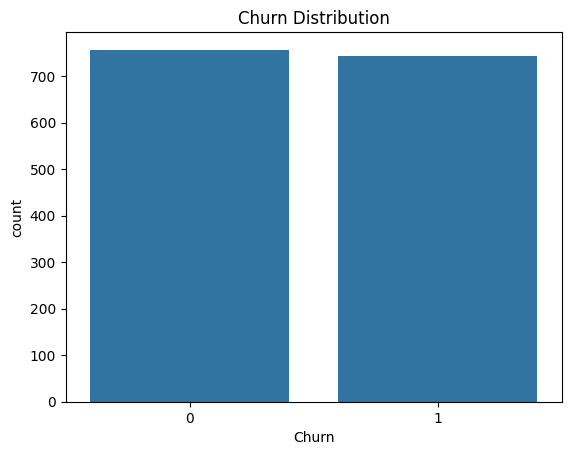

Churn
0    0.504667
1    0.495333
Name: proportion, dtype: float64


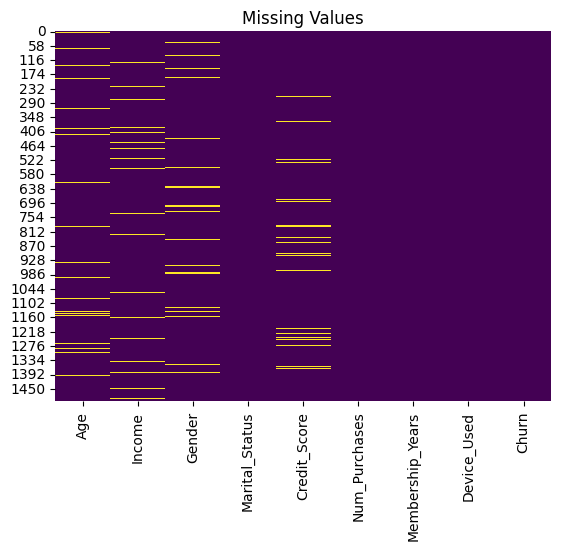

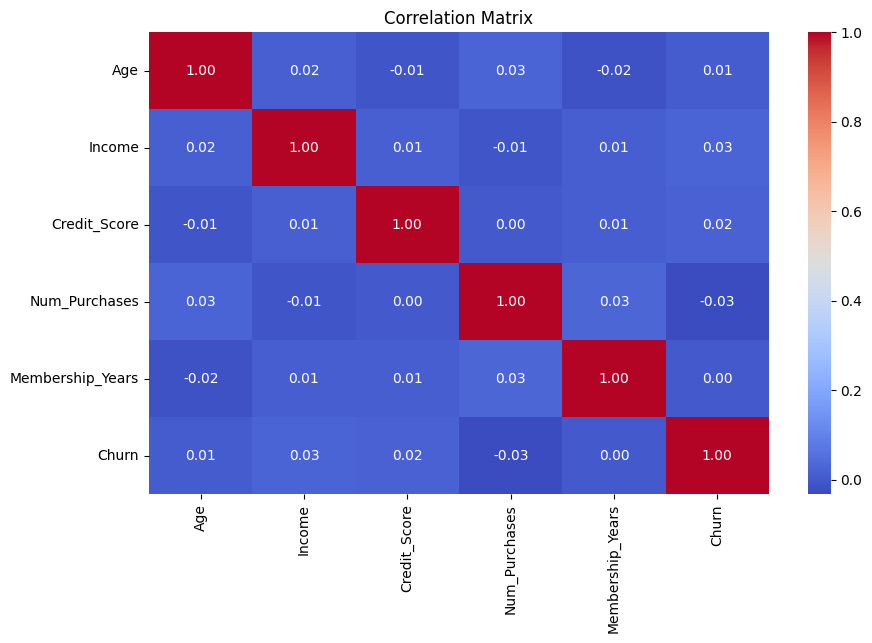

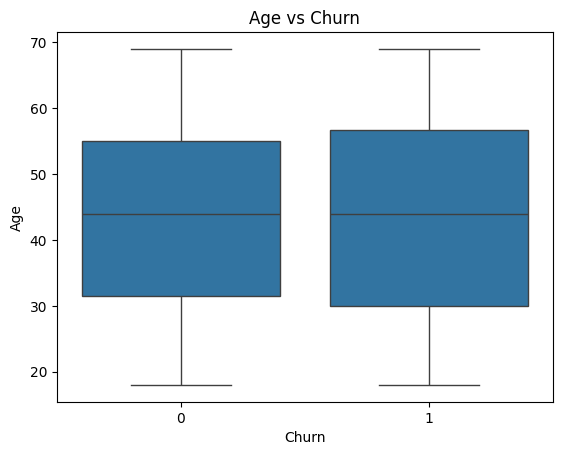

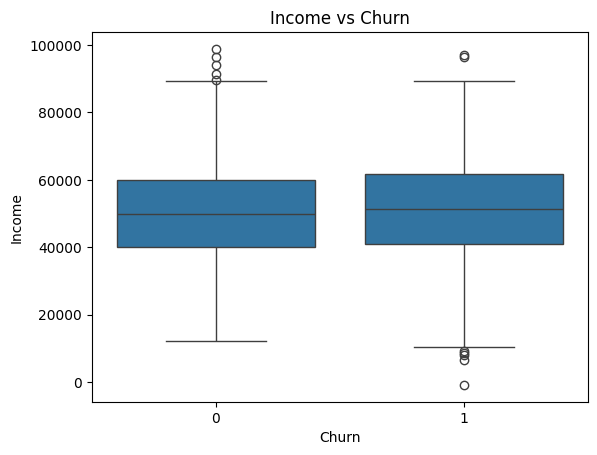

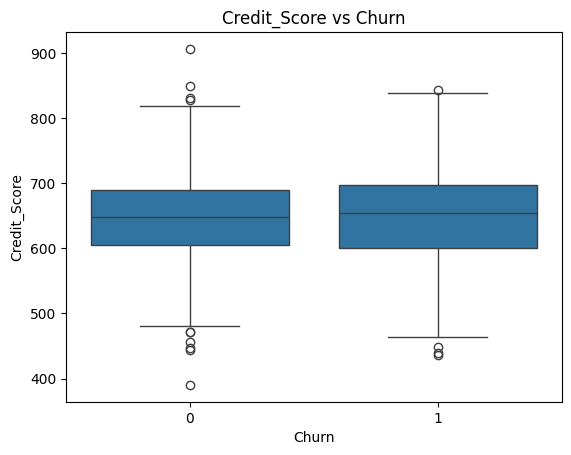

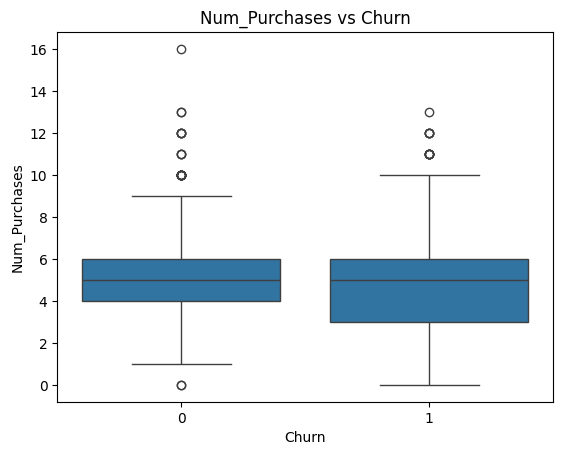

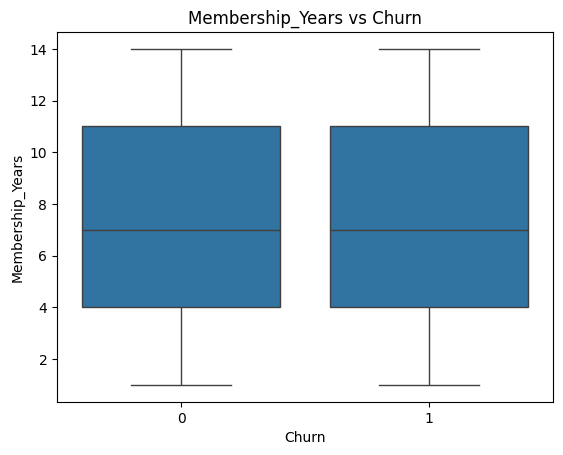

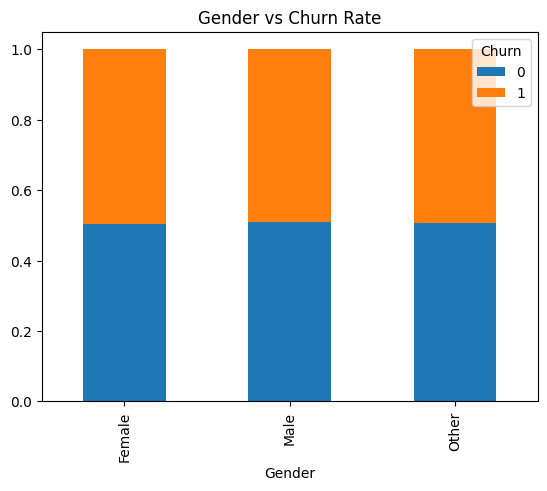

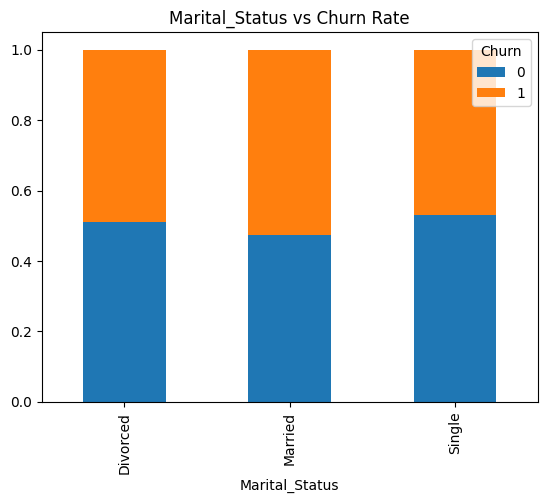

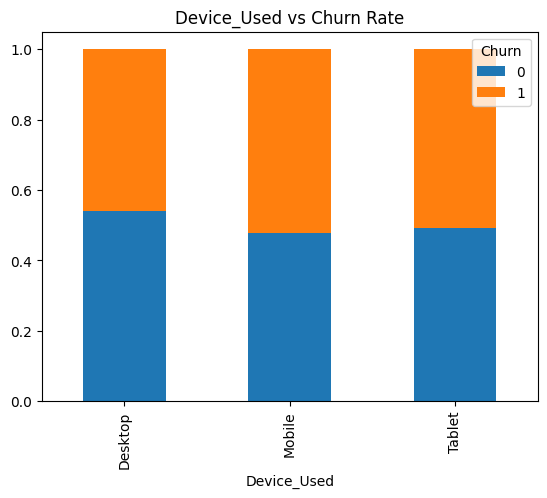

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Churn distribution (class imbalance check)
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()
print(df['Churn'].value_counts(normalize=True))

# 2. Missing value heatmap
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values")
plt.show()

# 3. Correlation heatmap (numeric only)
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# 4. Distribution of numeric features by Churn
for col in ['Age', 'Income', 'Credit_Score', 'Num_Purchases', 'Membership_Years']:
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'{col} vs Churn')
    plt.show()

# 5. Categorical feature vs Churn
for col in ['Gender', 'Marital_Status', 'Device_Used']:
    ct = pd.crosstab(df[col], df['Churn'], normalize='index')
    ct.plot(kind='bar', stacked=True)
    plt.title(f'{col} vs Churn Rate')
    plt.show()

In [ ]:
df = df.drop_duplicates()
print("After dropping duplicates:", df.shape)

After dropping duplicates: (1500, 9)


In [ ]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Income'].fillna(df['Income'].median(), inplace=True)
df['Credit_Score'].fillna(df['Credit_Score'].median(), inplace=True)

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Marital_Status'].fillna(df['Marital_Status'].mode()[0], inplace=True)

print("Missing after fill:", df.isnull().sum().sum())

Missing after fill: 0


/tmp/ipykernel_10455/2550527673.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_10455/2550527673.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [ ]:
##Handling Outliers
for col in ['Age', 'Income', 'Credit_Score']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

for col in ['Age', 'Income', 'Credit_Score']:
    lower_cap = df[col].quantile(0.01)
    upper_cap = df[col].quantile(0.99)
    df[col]   = df[col].clip(lower=lower_cap, upper=upper_cap)

for col in ['Age', 'Income', 'Credit_Score']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()


In [ ]:
cols_to_encode = [
    c for c in ['Gender', 'Marital_Status', 'Device_Used']
    if c in df.columns and df[c].dtype == 'object'
]

df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)
print("Shape after encoding:", df.shape)
print("Columns now:", list(df.columns))


Shape after encoding: (1500, 12)
Columns now: ['Age', 'Income', 'Credit_Score', 'Num_Purchases', 'Membership_Years', 'Churn', 'Gender_Male', 'Gender_Other', 'Marital_Status_Married', 'Marital_Status_Single', 'Device_Used_Mobile', 'Device_Used_Tablet']


In [ ]:
y = df['Churn']
X = df.drop('Churn', axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (1200, 11) | Test size: (300, 11)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("X_train:", X_train_scaled.shape, "| X_test:", X_test_scaled.shape)

X_train: (1200, 11) | X_test: (300, 11)


Variance explained by 2 components: 28.0%


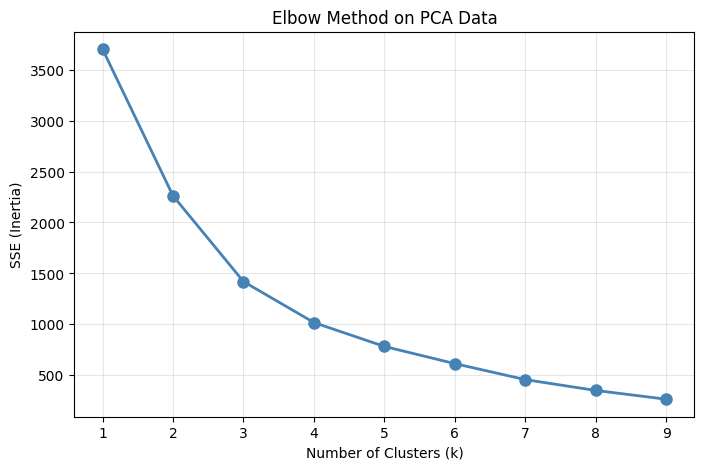

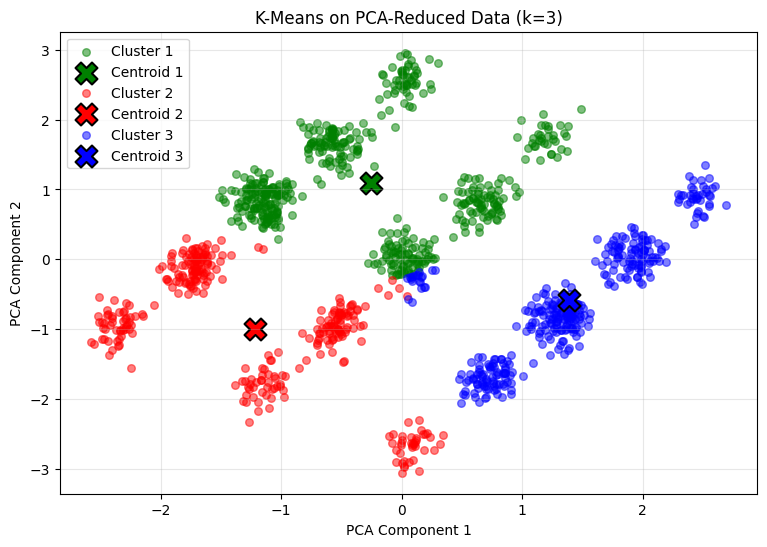


--- Churn rate per cluster ---
         Churn Rate  Size
Cluster                  
0             0.511   499
1             0.474   327
2             0.492   374


In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

print(f"Variance explained by 2 components: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

SSE = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    SSE.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1,10), SSE, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method on PCA Data')
plt.xticks(range(1,10))
plt.grid(True, alpha=0.3)
plt.show()

best_k = 3
km_pca = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_pca.fit_predict(X_pca)

colors = ['green', 'red', 'blue']
plt.figure(figsize=(9, 6))

for i in range(best_k):
    mask = cluster_labels == i
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=colors[i], label=f'Cluster {i+1}',
        alpha=0.5, s=30
    )
    plt.scatter(
        km_pca.cluster_centers_[i, 0],
        km_pca.cluster_centers_[i, 1],
        color=colors[i], s=250, marker='X',
        edgecolors='black', linewidths=1.5,
        label=f'Centroid {i+1}'
    )

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'K-Means on PCA-Reduced Data (k={best_k})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

import pandas as pd
import numpy as np

cluster_df = pd.DataFrame({
    'PCA1'    : X_pca[:, 0],
    'PCA2'    : X_pca[:, 1],
    'Cluster' : cluster_labels,
    'Churn'   : y_train.values
})

print("\n--- Churn rate per cluster ---")
summary = cluster_df.groupby('Cluster')['Churn'].agg(['mean','count'])
summary.columns = ['Churn Rate', 'Size']
summary['Churn Rate'] = summary['Churn Rate'].round(3)
print(summary)



Epoch 45: early stopping
Restoring model weights from the end of the best epoch: 30.
Stopped at epoch: 45


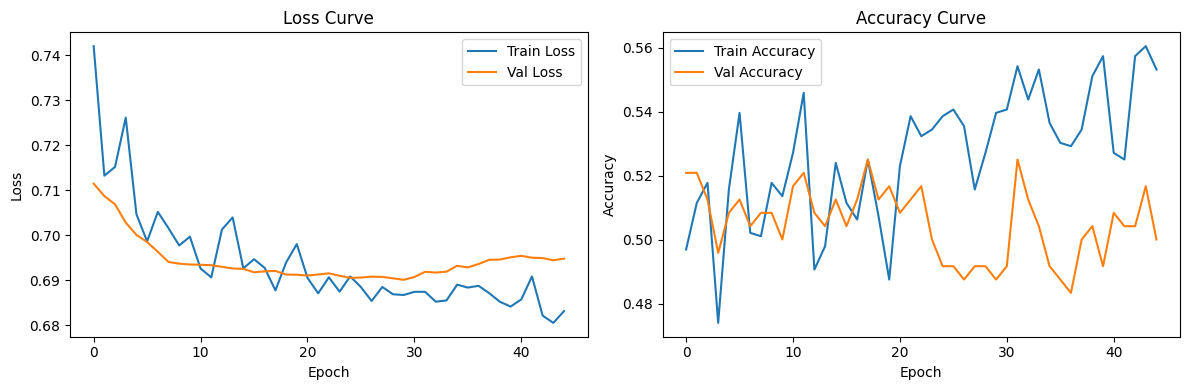

Test Accuracy: 51.33%
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.5),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print(f"Stopped at epoch: {len(history.history['loss'])}")

# plot
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {round(test_acc * 100, 2)}%")

y_pred_prob = model.predict(X_test_scaled)
y_pred_nn   = (y_pred_prob > 0.5).astype(int).flatten()

In [ ]:

# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=10,
    random_state=42
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)



In [ ]:

# LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr      = lr.predict(X_test_scaled)
y_pred_prob_lr = lr.predict_proba(X_test_scaled)[:,1]


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


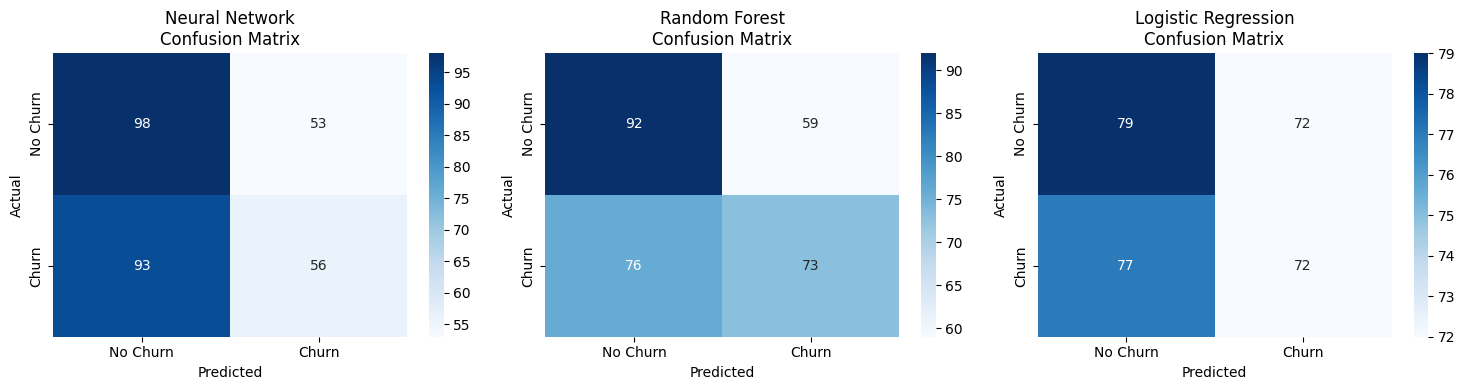

Model                 Accuracy  Precision   Recall       F1
Neural Network          0.5133     0.5138   0.3758   0.4341
Random Forest           0.5500     0.5530   0.4899   0.5196
Logistic Regression     0.5033     0.5000   0.4832   0.4915

--- Neural Network ---
              precision    recall  f1-score   support

    No Churn       0.51      0.65      0.57       151
       Churn       0.51      0.38      0.43       149

    accuracy                           0.51       300
   macro avg       0.51      0.51      0.50       300
weighted avg       0.51      0.51      0.50       300


--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.55      0.61      0.58       151
       Churn       0.55      0.49      0.52       149

    accuracy                           0.55       300
   macro avg       0.55      0.55      0.55       300
weighted avg       0.55      0.55      0.55       300


--- Logistic Regression ---
              precision    rec

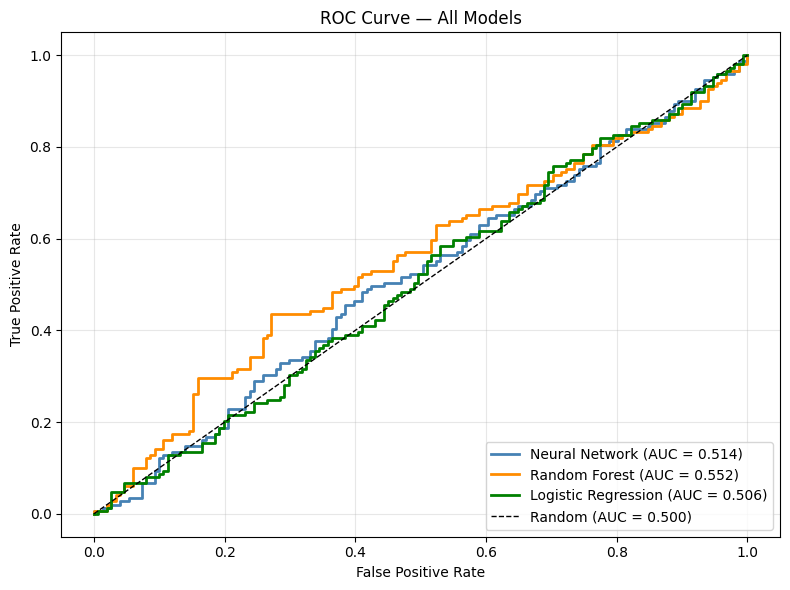


--- AUC Scores ---
Neural Network       AUC: 0.5143
Random Forest        AUC: 0.5524
Logistic Regression  AUC: 0.5057

Best model by F1 score: Random Forest
  Accuracy : 0.5500
  Precision: 0.5530
  Recall   : 0.4899
  F1 Score : 0.5196
  AUC      : 0.5524


In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


models = {
    'Neural Network' : (y_pred_nn,  model.predict(X_test_scaled).flatten()),
    'Random Forest'  : (y_pred_rf,  rf.predict_proba(X_test_scaled)[:,1]),
    'Logistic Regression'  : (y_pred_lr,  lr.predict_proba(X_test_scaled)[:,1]),
}


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (y_pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'])
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


print("=" * 60)
print(f"{'Model':<20} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("=" * 60)

results = {}
for name, (y_pred, y_prob) in models.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob)
    results[name] = (acc, prec, rec, f1, auc)
    print(f"{name:<20} {acc:>9.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f}")

print("=" * 60)

for name, (y_pred, _) in models.items():
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred,
          target_names=['No Churn', 'Churn']))


# ROC CURVE
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'green']

for (name, (y_pred, y_prob)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score   = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# AUC SCORE
print("\n--- AUC Scores ---")
for name, (acc, prec, rec, f1, auc) in results.items():
    print(f"{name:<20} AUC: {auc:.4f}")


best = max(results, key=lambda x: results[x][3])
print(f"\nBest model by F1 score: {best}")
print(f"  Accuracy : {results[best][0]:.4f}")
print(f"  Precision: {results[best][1]:.4f}")
print(f"  Recall   : {results[best][2]:.4f}")
print(f"  F1 Score : {results[best][3]:.4f}")
print(f"  AUC      : {results[best][4]:.4f}")